## Objective: What drives Points? 
### I will be looking at the last 3 seasons to see if i can find any insight on what helps predict points

In [1]:
import argparse
import warnings
from datetime import datetime
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
warnings.filterwarnings("ignore")
 
from pathlib import Path
import sys
import os

project_root = Path.cwd()
while not (project_root / "src").is_dir() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

from src.utils.db import read_df

### Load Data

In [2]:
df = read_df("nba_player_gamelogs", schema="silver")
print(f"silver.nba_player_gamelogs: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head()

silver.nba_player_gamelogs: 165,238 rows × 192 cols


,game_id,player_id,built_at,season_year,season_type,player_name,nickname,team_id,team_abbreviation,team_name,game_date,matchup,wl,min,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,ftm,fta,ft_pct,oreb,dreb,reb,ast,tov,stl,blk,blka,pf,pfd,pts,plus_minus,nba_fantasy_pts,dd2,td3,wnba_fantasy_pts,available_flag,min_sec,team_count,e_off_rating,off_rating,sp_work_off_rating,e_def_rating,def_rating,sp_work_def_rating,e_net_rating,net_rating,sp_work_net_rating,ast_pct,ast_to,ast_ratio,oreb_pct,dreb_pct,reb_pct,tm_tov_pct,e_tov_pct,efg_pct,ts_pct,usg_pct,e_usg_pct,e_pace,pace,pace_per40,sp_work_pace,pie,poss,fgm_pg,fga_pg,team_city,team_tricode,team_slug,first_name,family_name,name_i,player_slug,start_position,comment,jersey_num,minutes,spd,dist,orbc,drbc,rbc,tchs,sast,ftast,pass,assists,cfgm,cfga,cfg_pct,ufgm,ufga,ufg_pct,field_goal_percentage,dfgm,dfga,dfg_pct,team_fgm,team_fga,team_fg_pct,team_fg3m,team_fg3a,team_fg3_pct,team_ftm,team_fta,team_ft_pct,team_oreb,team_dreb,team_reb,team_ast,team_tov,team_stl,team_blk,team_blka,team_pf,team_pfd,team_pts,team_plus_minus,team_e_off_rating,team_off_rating,team_e_def_rating,team_def_rating,team_e_net_rating,team_net_rating,team_ast_pct,team_ast_to,team_ast_ratio,team_oreb_pct,team_dreb_pct,team_reb_pct,team_tm_tov_pct,team_efg_pct,team_ts_pct,team_e_pace,team_pace,team_pace_per40,team_poss,team_pie,opp_team_id,opp_team_abbreviation,opp_team_name,opp_fgm,opp_fga,opp_fg_pct,opp_fg3m,opp_fg3a,opp_fg3_pct,opp_ftm,opp_fta,opp_ft_pct,opp_oreb,opp_dreb,opp_reb,opp_ast,opp_tov,opp_stl,opp_blk,opp_blka,opp_pf,opp_pfd,opp_pts,opp_plus_minus,opp_e_off_rating,opp_off_rating,opp_e_def_rating,opp_def_rating,opp_e_net_rating,opp_net_rating,opp_ast_pct,opp_ast_to,opp_ast_ratio,opp_oreb_pct,opp_dreb_pct,opp_reb_pct,opp_tm_tov_pct,opp_efg_pct,opp_ts_pct,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,pos,age,is_playoff,team_spread,game_total
0,0022301194,1630240,2026-07-12 19:18:00.820422+00:00,2023-24,Regular Season,Saben Lee,Saben,1610612756,PHX,Phoenix Suns,2024-04-14,PHX @ MIN,W,4.566667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-5.0,0.0,0.0,0.0,0.0,1,4:34,1.0,133.3,120.0,120.0,164.7,170.0,170.0,-31.4,-50.0,-50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101.54,105.11,87.59,105.11,0.000,10.0,0.0,0.0,Phoenix,PHX,suns,Saben,Lee,S. Lee,saben-lee,None,None,38,4:34,4.35,0.37,0.0,0.0,0.0,8.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.0,86.0,0.547,16.0,29.0,0.552,15.0,18.0,0.833,13.0,19.0,32.0,28.0,13.0,13.0,3.0,5.0,24.0,20.0,125.0,19.0,133.1,133.0,110.8,114.0,22.3,19.0,0.596,2.15,20.4,0.366,0.600,0.474,0.138,0.640,0.665,94.8,93.5,77.92,94.0,0.577,1610612750,None,None,36.0,70.0,0.514,9.0,26.0,0.346,25.0,31.0,0.806,12.0,24.0,36.0,22.0,24.0,7.0,5.0,3.0,20.0,24.0,106.0,-19.0,110.8,114.0,133.1,133.0,-22.3,-19.0,0.611,0.92,17.2,0.400,0.634,0.526,0.258,0.579,0.634,94.8,93.5,77.92,93.0,0.423,PG,None,None,-2.5,217.0
1,0022301148,1641753,2026-07-12 19:18:00.820422+00:00,2023-24,Regular Season,Chris Livingston,Chris,1610612749,MIL,Milwaukee Bucks,2024-04-09,MIL vs. BOS,W,0.460000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,1,0:28,1.0,0.0,0.0,0.0,200.0,200.0,200.0,-200.0,-200.0,-200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.17,104.35,86.96,104.35,0.000,1.0,0.0,0.0,Milwaukee,MIL,bucks,Chris,Livingston,C. Livingston,chris-livingston,None,None,7,0:28,3.00,0.03,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,81.0,0.531,17.0,36.0,0.472,1.0,2.0,0.500,10.0,39.0,49.0,29.0,18.0,6.0,5.0,4.0,4.0,8.0,104.0,13.0,115.7,115.6,97.8,101.1,17.9,14.4,0.674,1.61,22.1,0.308,0.714,0.547,0.200,0.636,0.635,91.4,90.0,75.00,90.0,0.589,1610612738,None,None,37.0,93.0,0.398,17.0,52.0,0.327,0.0,0.0,0.000,12.0,26.0,38.0,27.0,12.0,11.0,4.0,5.0,8.0,4.0,91.0,-13.0,97.8,101.1,115.7,115.6,-17.9,-14.4,0.730,2.25,20.3,0.286,0.692,0.453,0.133,0.489,0.489,91.4,90.0,75.00,90.0,0.411,SF,None,None,-3.5,230.5
2,002230113

## Data Quality 

In [3]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

TARGET = "pts"  # Points

# Columns that mechanically define/derive points in the SAME row — leakage risk
LEAKAGE_DIRECT = [
    "fgm", "fga", "fg_pct", "fg3m", "fg3a", "fg3_pct", "ftm", "fta", "ft_pct",
    "cfgm", "cfga", "cfg_pct", "ufgm", "ufga", "ufg_pct",
    "efg_pct", "ts_pct", "field_goal_percentage", "fgm_pg", "fga_pg",
]
LEAKAGE_COMPOSITE = [
    "nba_fantasy_pts", "wnba_fantasy_pts", "pie", "plus_minus", "dd2", "td3",
    "off_rating", "e_off_rating", "sp_work_off_rating",
    "net_rating", "e_net_rating", "sp_work_net_rating",
]
LEAKAGE_TEAM_LEVEL = ["team_pts", "team_plus_minus", "team_fg_pct"]

PCT_COLUMNS = [
    "fg_pct", "fg3_pct", "ft_pct", "oreb_pct", "dreb_pct", "reb_pct",
    "tm_tov_pct", "e_tov_pct", "efg_pct", "ts_pct", "usg_pct", "e_usg_pct",
    "ast_pct", "cfg_pct", "ufg_pct", "field_goal_percentage", "dfg_pct",
    "team_fg_pct", "team_fg3_pct", "team_ft_pct", "team_oreb_pct",
    "team_dreb_pct", "team_reb_pct", "team_tm_tov_pct", "team_efg_pct",
    "team_ts_pct", "team_ast_pct", "team_pie",
    "opp_fg_pct", "opp_fg3_pct", "opp_ft_pct", "opp_oreb_pct",
    "opp_dreb_pct", "opp_reb_pct", "opp_tm_tov_pct", "opp_efg_pct",
    "opp_ts_pct", "opp_ast_pct", "opp_pie", "pie",
]
NON_NEGATIVE_COLUMNS = [
    "min", "fgm", "fga", "fg3m", "fg3a", "ftm", "fta", "oreb", "dreb", "reb",
    "ast", "tov", "stl", "blk", "blka", "pf", "pfd", "pts", "poss", "age",
    "dist", "spd", "tchs", "pass", "sast", "ftast",
]
MADE_ATTEMPTED_PAIRS = [
    ("fgm", "fga"), ("fg3m", "fg3a"), ("ftm", "fta"),
    ("team_fgm", "team_fga"), ("team_fg3m", "team_fg3a"), ("team_ftm", "team_fta"),
    ("opp_fgm", "opp_fga"), ("opp_fg3m", "opp_fg3a"), ("opp_ftm", "opp_fta"),
    ("cfgm", "cfga"), ("ufgm", "ufga"), ("dfgm", "dfga"),
]
TRACKING_ERA_COLUMNS = [
    "spd", "dist", "orbc", "drbc", "rbc", "tchs", "sast", "ftast", "pass",
    "assists", "cfgm", "cfga", "cfg_pct", "ufgm", "ufga", "ufg_pct",
    "dfgm", "dfga", "dfg_pct", "field_goal_percentage",
]
NATURAL_KEY = ["game_id", "player_id"]
EXPECTED_ID_COLUMNS = [
    "game_id", "player_id", "team_id", "opp_team_id", "player_slug",
    "team_slug", "built_at", "game_date",
]

print(f"df shape: {df.shape}")

df shape: (165238, 192)


## Per-column profile (dtype, missing %, cardinality, outliers, memory)

In [4]:
def cardinality_bucket(nunique, n_rows):
    if n_rows == 0:
        return "empty"
    ratio = nunique / n_rows
    if nunique <= 1:
        return "constant"
    if nunique == 2:
        return "binary"
    if ratio > 0.95:
        return "id-like (near-unique)"
    if nunique <= 10:
        return "low"
    if nunique <= 50:
        return "medium"
    return "high"

def iqr_outlier_pct(series):
    s = series.dropna()
    if len(s) < 10 or s.nunique() <= 1:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return 100.0 * ((s < lo) | (s > hi)).mean()

n_rows = len(df)
rows = []
for col in df.columns:
    s = df[col]
    n_missing = s.isna().sum()
    nunique = s.nunique(dropna=True)
    non_null = s.dropna()
    top_share = (non_null.value_counts(normalize=True).iloc[0] * 100) if len(non_null) else np.nan
    is_numeric = pd.api.types.is_numeric_dtype(s)
    rows.append({
        "column": col,
        "dtype": str(s.dtype),
        "pct_missing": round(100 * n_missing / n_rows, 3) if n_rows else np.nan,
        "nunique": nunique,
        "cardinality": cardinality_bucket(nunique, n_rows),
        "top_value_share_pct": round(top_share, 2) if pd.notna(top_share) else np.nan,
        "is_constant": nunique <= 1,
        "is_near_constant": (top_share >= 99.0) if pd.notna(top_share) else False,
        "is_numeric": is_numeric,
        "outlier_pct_iqr": round(iqr_outlier_pct(s), 3) if is_numeric else np.nan,
        "memory_MB": round(s.memory_usage(deep=True) / 1e6, 4),
        "is_tracking_era_col": col in TRACKING_ERA_COLUMNS,
        "is_leakage_direct": col in LEAKAGE_DIRECT,
        "is_leakage_composite": col in LEAKAGE_COMPOSITE,
        "is_leakage_team_level": col in LEAKAGE_TEAM_LEVEL,
    })

profile_df = pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
profile_df[:50]

,column,dtype,pct_missing,nunique,cardinality,top_value_share_pct,is_constant,is_near_constant,is_numeric,outlier_pct_iqr,memory_MB,is_tracking_era_col,is_leakage_direct,is_leakage_composite,is_leakage_team_level
0,opp_team_abbreviation,object,100.000,0,constant,NaN,True,False,False,NaN,3.9658,False,False,False,False
1,opp_team_name,object,100.000,0,constant,NaN,True,False,False,NaN,3.9658,False,False,False,False
2,is_playoff,object,100.000,0,constant,NaN,True,False,False,NaN,3.9658,False,False,False,False
3,age,object,100.000,0,constant,NaN,True,False,False,NaN,3.9658,False,False,False,False
4,comment,object,99.987,1,constant,100.00,True,True,False,NaN,3.9664,False,False,False,False
5,start_position,object,53.170,4,low,39.99,False,False,False,NaN,5.9777,False,False,False,False
6,game_total,float64,1.974,118,high,2.36,False,False,True,0.225,1.3220,False,False,False,False
7,team_spread,float64,1.665,87,high,3.71,False,False,True,0.028,1.3220,False,False,False,False
8,pos,object,0.616,7,low,23.33,False,False,False,NaN,8.3585,False,False,False,False
9,jersey_num,object,0.231,76,high,5.02,False,False,False,NaN,8.3528,False,False,False,False


## Dataset summary

In [5]:
n_full_dup = int(df.duplicated(keep=False).sum())
total_mem_mb = df.memory_usage(deep=True).sum() / 1e6

print(f"Rows: {n_rows:,}")
print(f"Columns: {df.shape[1]}")
print(f"Total memory (deep): {total_mem_mb:.2f} MB")
print(f"Fully duplicated rows: {n_full_dup:,}")
if "season_year" in df.columns:
    print(f"Season range: {df['season_year'].min()} → {df['season_year'].max()}")

Rows: 165,238
Columns: 192
Total memory (deep): 443.94 MB
Fully duplicated rows: 0
Season range: 2020-21 → 2025-26


## Constant / near-constant columns

In [6]:
const_cols = profile_df.loc[profile_df["is_constant"], "column"].tolist()
near_const = profile_df.loc[profile_df["is_near_constant"] & ~profile_df["is_constant"], "column"].tolist()

print("Constant columns:", const_cols or "none")
print("Near-constant columns:", near_const or "none")

Constant columns: ['opp_team_abbreviation', 'opp_team_name', 'is_playoff', 'age', 'comment', 'team_count']
Near-constant columns: ['td3', 'available_flag']


## Duplicate natural key check (game_id + player_id)

In [7]:
key_cols = [c for c in NATURAL_KEY if c in df.columns]
dup_mask = df.duplicated(subset=key_cols, keep=False)
n_dup = int(dup_mask.sum())

print(f"Duplicate {key_cols} rows: {n_dup:,}")

if n_dup > 0 and "team_count" in df.columns:
    unexplained = df.loc[dup_mask & (df["team_count"] <= 1)]
    print(f"  -> explained by team_count > 1 (traded players): {n_dup - len(unexplained):,}")
    print(f"  -> UNEXPLAINED duplicates (investigate): {len(unexplained):,}")
    display(unexplained.head(10))

Duplicate ['game_id', 'player_id'] rows: 0


# Target Analysis

### Setup for target analysis

In [8]:
from scipy import stats

TARGET = "pts"
y = df[TARGET].dropna()

print(f"n observations: {len(y):,}")

n observations: 165,238


### Core descriptive statistics

In [9]:
desc = {
    "mean": y.mean(),
    "median": y.median(),
    "variance": y.var(),
    "std": y.std(),
    "skew": stats.skew(y),
    "kurtosis_excess": stats.kurtosis(y),  # 0 = normal, >0 = heavy-tailed, <0 = light-tailed
    "min": y.min(),
    "max": y.max(),
    "p01": y.quantile(0.01),
    "p05": y.quantile(0.05),
    "p25": y.quantile(0.25),
    "p75": y.quantile(0.75),
    "p95": y.quantile(0.95),
    "p99": y.quantile(0.99),
}
desc_df = pd.Series(desc).round(3)
desc_df

mean               10.599
median              9.000
variance           78.152
std                 8.840
skew                1.027
kurtosis_excess     1.000
min                 0.000
max                83.000
p01                 0.000
p05                 0.000
p25                 4.000
p75                16.000
p95                28.000
p99                37.000
dtype: float64

### Outlier detection (IQR + z-score)

In [10]:
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_outlier_pct = ((y < lo) | (y > hi)).mean() * 100

z = (y - y.mean()) / y.std()
z_outlier_pct = (z.abs() > 3).mean() * 100

print(f"IQR bounds: [{lo:.1f}, {hi:.1f}]  -> {iqr_outlier_pct:.2f}% of games flagged as outliers")
print(f"|z| > 3 -> {z_outlier_pct:.2f}% of games flagged as outliers")
print(f"Top 10 highest-scoring games:\n{y.sort_values(ascending=False).head(10)}")

IQR bounds: [-14.0, 34.0]  -> 1.53% of games flagged as outliers
|z| > 3 -> 0.85% of games flagged as outliers
Top 10 highest-scoring games:
143693    83.0
11991     73.0
137204    71.0
129781    71.0
12618     70.0
18956     64.0
12619     62.0
11992     62.0
121222    62.0
2780      61.0
Name: pts, dtype: float64


### Histogram

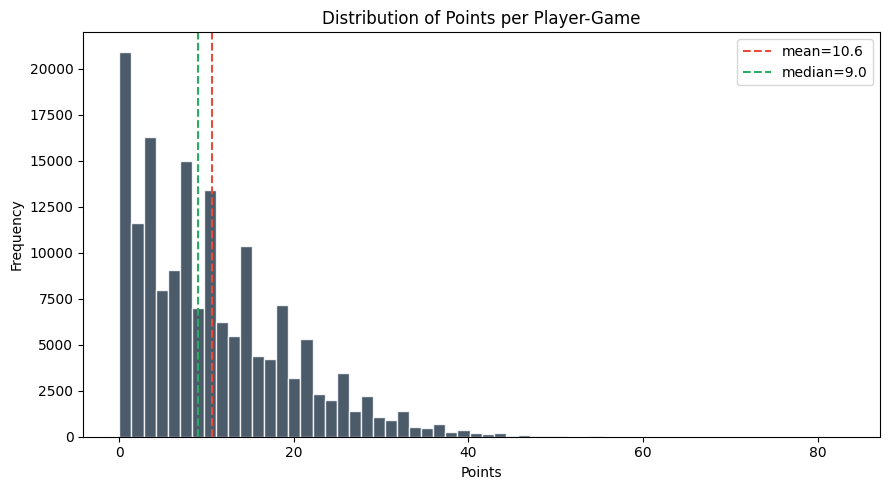

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y, bins=60, color="#2c3e50", edgecolor="white", alpha=0.85)
ax.axvline(y.mean(), color="#e74c3c", linestyle="--", label=f"mean={y.mean():.1f}")
ax.axvline(y.median(), color="#27ae60", linestyle="--", label=f"median={y.median():.1f}")
ax.set_xlabel("Points")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Points per Player-Game")
ax.legend()
plt.tight_layout()
plt.show()

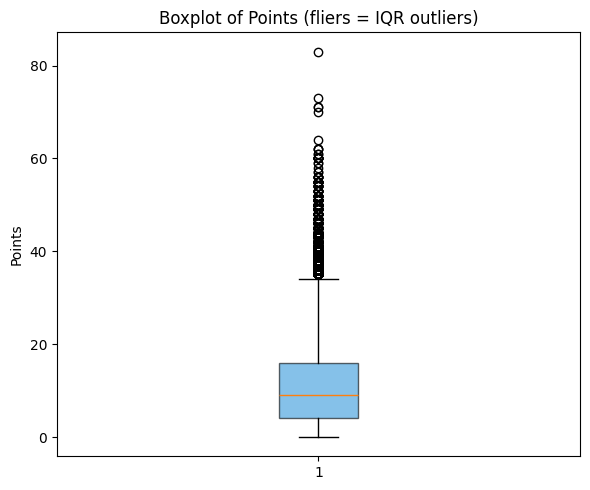

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(y, vert=True, showfliers=True, patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6))
ax.set_ylabel("Points")
ax.set_title("Boxplot of Points (fliers = IQR outliers)")
plt.tight_layout()
plt.show()

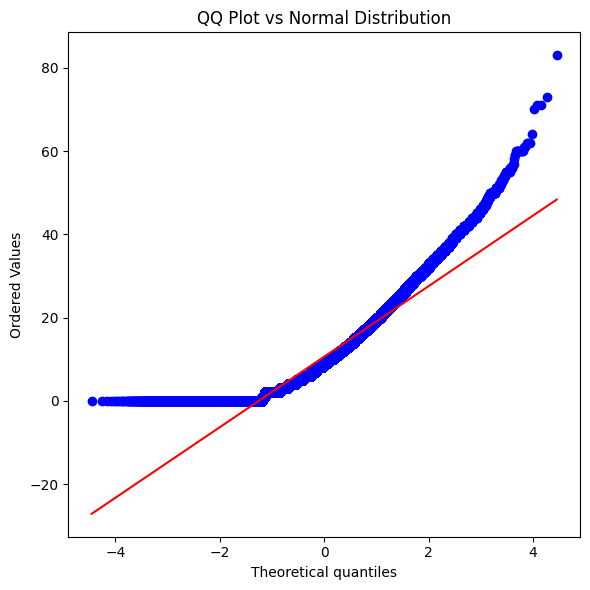

Shapiro-Wilk (n=5000): stat=0.9235, p=8.10e-45


In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(y, dist="norm", plot=ax)
ax.set_title("QQ Plot vs Normal Distribution")
plt.tight_layout()
plt.show()

# Formal normality test (Shapiro on a sample since it's sensitive to n > 5000)
sample_for_test = y.sample(min(5000, len(y)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_for_test)
print(f"Shapiro-Wilk (n={len(sample_for_test)}): stat={shapiro_stat:.4f}, p={shapiro_p:.2e}")

### Seasonality: by season, month, day-of-week, playoff vs regular

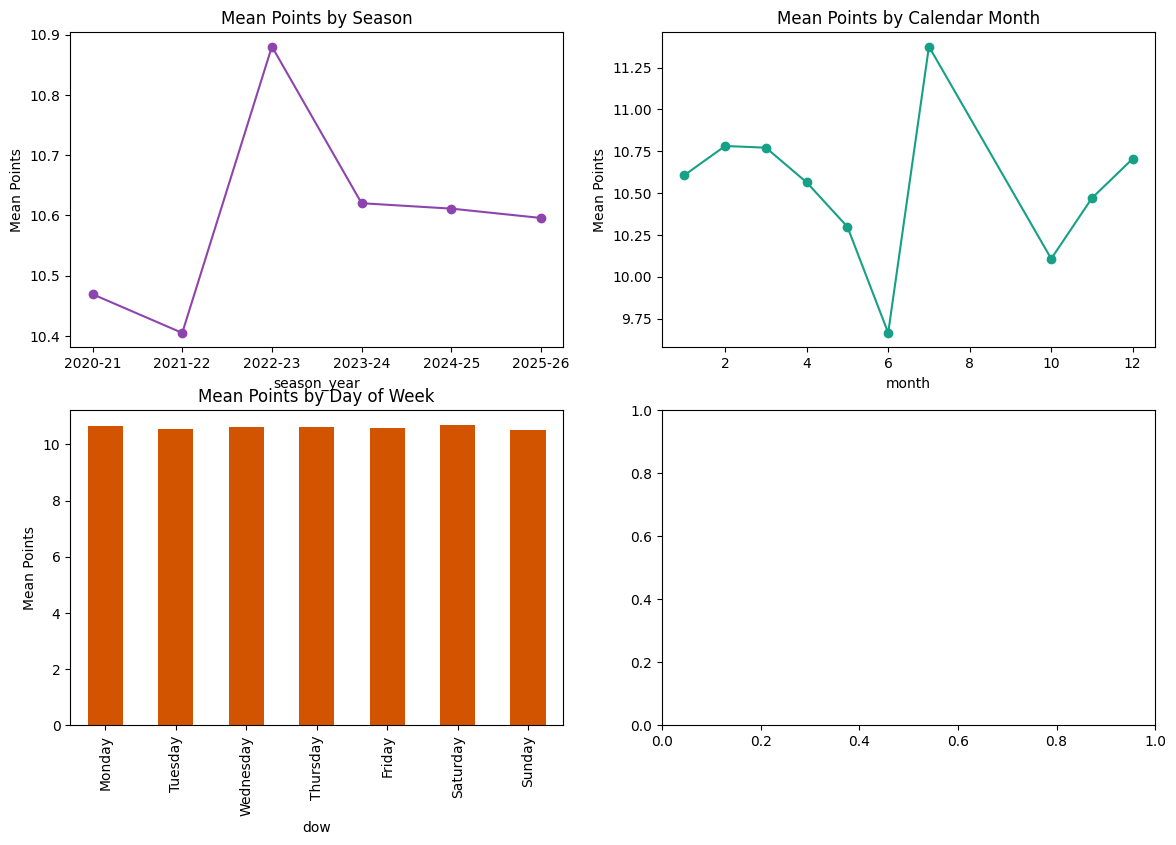

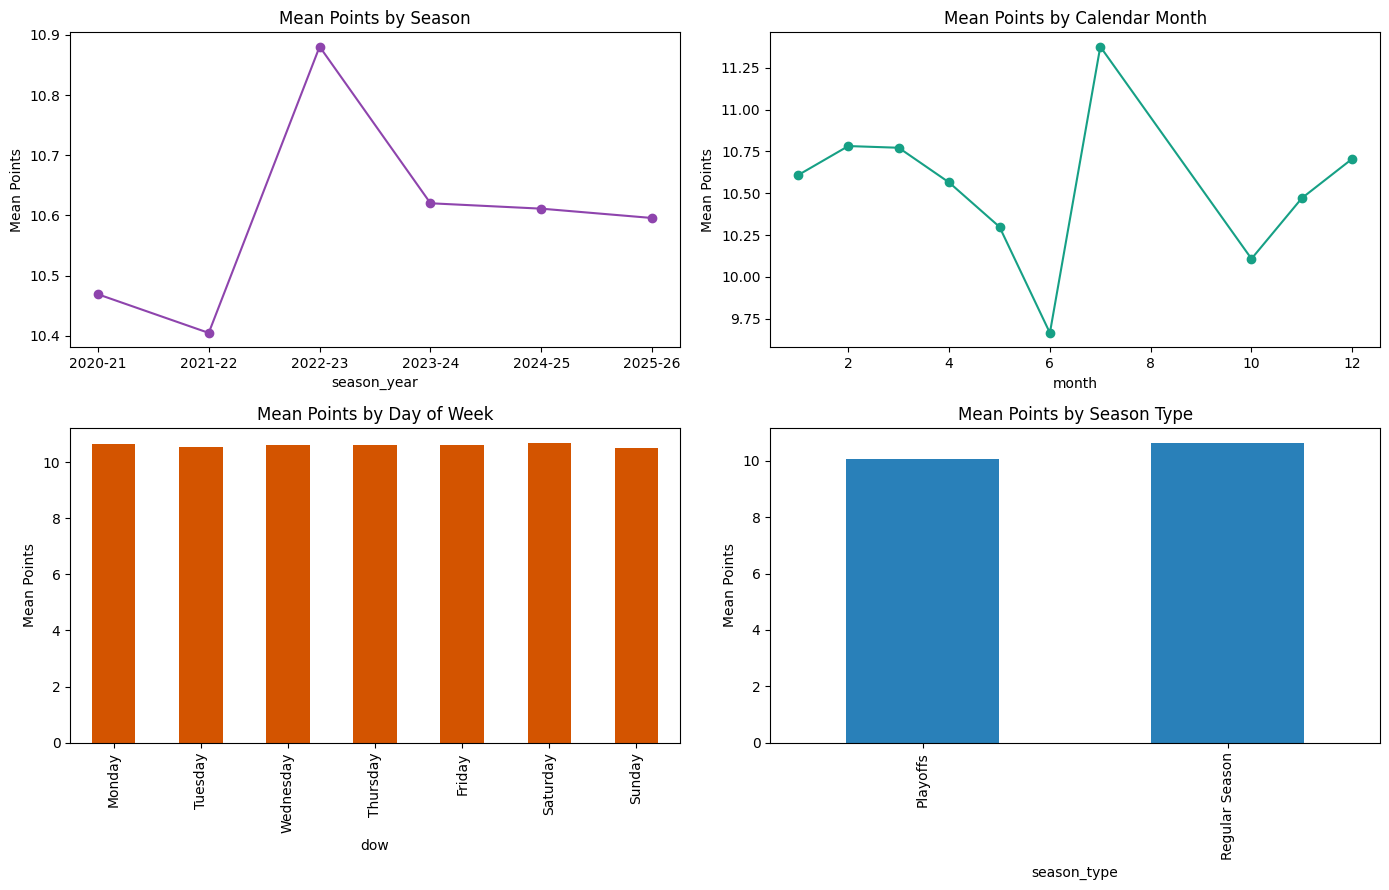

<Figure size 640x480 with 0 Axes>

In [14]:
df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
df["month"] = df["game_date"].dt.month
df["dow"] = df["game_date"].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if "season_year" in df.columns:
    df.groupby("season_year")[TARGET].mean().plot(ax=axes[0, 0], marker="o", color="#8e44ad")
    axes[0, 0].set_title("Mean Points by Season")
    axes[0, 0].set_ylabel("Mean Points")

df.groupby("month")[TARGET].mean().plot(ax=axes[0, 1], marker="o", color="#16a085")
axes[0, 1].set_title("Mean Points by Calendar Month")
axes[0, 1].set_ylabel("Mean Points")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("dow")[TARGET].mean().reindex(dow_order).plot(kind="bar", ax=axes[1, 0], color="#d35400")
axes[1, 0].set_title("Mean Points by Day of Week")
axes[1, 0].set_ylabel("Mean Points")

df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
df["month"] = df["game_date"].dt.month
df["dow"] = df["game_date"].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if "season_year" in df.columns:
    df.groupby("season_year")[TARGET].mean().plot(ax=axes[0, 0], marker="o", color="#8e44ad")
    axes[0, 0].set_title("Mean Points by Season")
    axes[0, 0].set_ylabel("Mean Points")

df.groupby("month")[TARGET].mean().plot(ax=axes[0, 1], marker="o", color="#16a085")
axes[0, 1].set_title("Mean Points by Calendar Month")
axes[0, 1].set_ylabel("Mean Points")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("dow")[TARGET].mean().reindex(dow_order).plot(kind="bar", ax=axes[1, 0], color="#d35400")
axes[1, 0].set_title("Mean Points by Day of Week")
axes[1, 0].set_ylabel("Mean Points")

# is_playoff is 100% null in silver — use season_type instead
if "season_type" in df.columns:
    df.groupby("season_type")[TARGET].mean().plot(kind="bar", ax=axes[1, 1], color="#2980b9")
    axes[1, 1].set_title("Mean Points by Season Type")
    axes[1, 1].set_ylabel("Mean Points")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### Trend: league-wide points over time

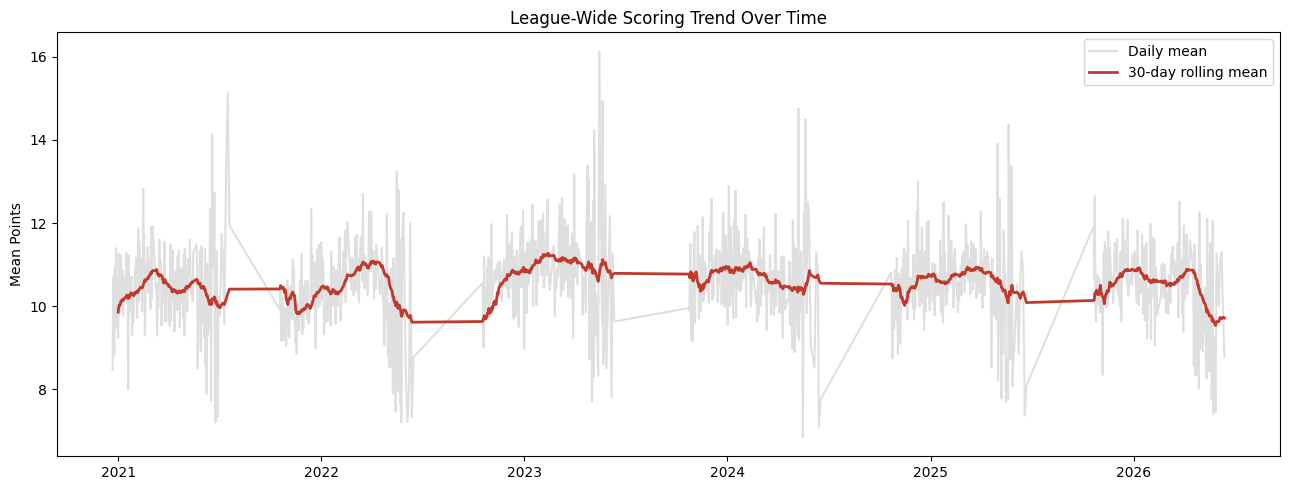

In [15]:
daily_avg = df.groupby("game_date")[TARGET].mean().sort_index()
rolling_30 = daily_avg.rolling(30, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_avg.index, daily_avg.values, alpha=0.25, color="gray", label="Daily mean")
ax.plot(rolling_30.index, rolling_30.values, color="#c0392b", linewidth=2, label="30-day rolling mean")
ax.set_title("League-Wide Scoring Trend Over Time")
ax.set_ylabel("Mean Points")
ax.legend()
plt.tight_layout()
plt.show()

### Autocorrelation (per-player game sequence, since this is panel data)

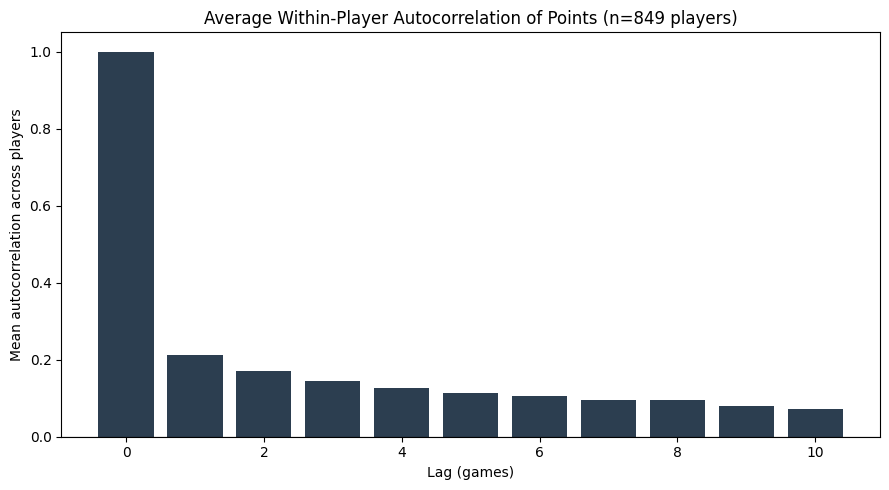

0     1.000
1     0.213
2     0.171
3     0.145
4     0.127
5     0.114
6     0.105
7     0.096
8     0.094
9     0.079
10    0.073
Name: mean_acf, dtype: float64


In [16]:
# IMPORTANT: pts is a PANEL (player x game), not a single time series.
# Pooling all rows by date mixes different players together, so autocorrelation
# must be computed WITHIN each player's own game sequence, then averaged.

from statsmodels.tsa.stattools import acf

MIN_GAMES = 20
N_LAGS = 10

player_counts = df.groupby("player_id")[TARGET].count()
eligible_players = player_counts[player_counts >= MIN_GAMES].index

acf_matrix = []
for pid in eligible_players:
    seq = df.loc[df["player_id"] == pid].sort_values("game_date")[TARGET].dropna()
    if len(seq) >= MIN_GAMES:
        vals = acf(seq, nlags=N_LAGS, fft=True)
        acf_matrix.append(vals)

acf_matrix = np.array(acf_matrix)
mean_acf = acf_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(N_LAGS + 1), mean_acf, color="#2c3e50")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag (games)")
ax.set_ylabel("Mean autocorrelation across players")
ax.set_title(f"Average Within-Player Autocorrelation of Points (n={len(acf_matrix)} players)")
plt.tight_layout()
plt.show()

print(pd.Series(mean_acf, name="mean_acf").round(3))

### Stationarity (ADF test, per-player summary)

In [17]:
from statsmodels.tsa.stattools import adfuller

adf_results = []
for pid in eligible_players:
    seq = df.loc[df["player_id"] == pid].sort_values("game_date")[TARGET].dropna()
    if len(seq) >= MIN_GAMES and seq.nunique() > 1:
        try:
            stat, pval, *_ = adfuller(seq, autolag="AIC")
            adf_results.append({"player_id": pid, "adf_stat": stat, "p_value": pval})
        except Exception:
            continue

adf_df = pd.DataFrame(adf_results)
pct_stationary = (adf_df["p_value"] < 0.05).mean() * 100

print(f"Players tested: {len(adf_df)}")
print(f"% with stationary points series (ADF p<0.05, reject unit root): {pct_stationary:.1f}%")
adf_df.sort_values("p_value").head(10)

Players tested: 849
% with stationary points series (ADF p<0.05, reject unit root): 79.4%


,player_id,adf_stat,p_value
127,203507,-19.436799,0.000000e+00
243,1628369,-21.540688,0.000000e+00
198,1626220,-20.762952,0.000000e+00
181,1626164,-19.558295,0.000000e+00
164,203999,-20.737762,0.000000e+00
186,1626171,-18.653609,2.049932e-30
363,1629611,-18.581165,2.077863e-30
211,1627750,-18.318508,2.268385e-30
244,1628370,-17.228073,6.218158e-30
254,1628384,-17.151317,6.939252e-30
